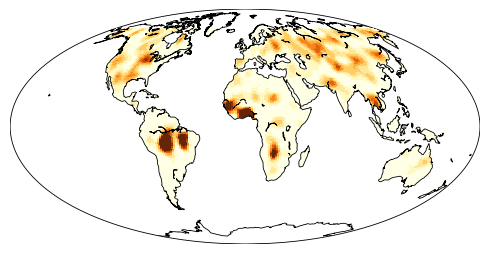

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from mpl_toolkits.basemap import Basemap
from scipy.interpolate import griddata

import geopandas as gpd
from shapely.geometry import Point
from shapely.prepared import prep

# Input and output files
file_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step_4_Event_Calculation\Event_Observ\Track_Count_Grid_5.0_1980-2000.xlsx"
land_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Data\natural_earth_vector\110m_physical\ne_110m_land.shp"

out_png = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\1980-2000_with_Track_Counts_ROBIN.png"
out_pdf = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\1980-2000_with_Track_Counts_ROBIN.pdf"
out_svg = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\1980-2000_with_Track_Counts_ROBIN.svg"

# Read event data
df = pd.read_excel(file_path)

lon = df["centroid_x"].to_numpy(dtype=float)
lat = df["centroid_y"].to_numpy(dtype=float)
val = df["track_count"].to_numpy(dtype=float)

# Remove invalid values
ok = np.isfinite(lon) & np.isfinite(lat) & np.isfinite(val)
lon, lat, val = lon[ok], lat[ok], val[ok]

# Create interpolation grid
grid_lon_1d = np.linspace(-180, 180, 240)
grid_lat_1d = np.linspace(-60, 70, 180)
grid_lon, grid_lat = np.meshgrid(grid_lon_1d, grid_lat_1d)

# Interpolate track counts
interp = griddata(
    (lon, lat),
    val,
    (grid_lon, grid_lat),
    method="cubic"
)

interp = np.where(interp < 0, 0, interp)

land = gpd.read_file(land_path).to_crs("EPSG:4326")

land = land[land.geometry.bounds["maxy"] > -60].copy()

# Merge land polygons
try:
    land_union = land.geometry.union_all()
except AttributeError:
    land_union = land.geometry.unary_union

land_union_p = prep(land_union)

# Create land mask
mask_land = np.zeros(grid_lon.shape, dtype=bool)

for i in range(grid_lon.shape[0]):
    for j in range(grid_lon.shape[1]):
        p = Point(grid_lon[i, j], grid_lat[i, j])
        mask_land[i, j] = land_union_p.intersects(p)

# Apply land mask
interp_land = np.where(mask_land, interp, np.nan)
interp_land = np.ma.masked_invalid(interp_land)

# Set color bins
levels = [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
cmap = plt.get_cmap("YlOrBr", len(levels) - 1)
norm = BoundaryNorm(levels, cmap.N, clip=True)

# Create figure
fig, ax = plt.subplots(figsize=(5, 4))

# Create Mollweide projection
m = Basemap(
    projection="moll",
    lon_0=0,
    resolution="c",
    ax=ax
)

# Draw map boundary
m.drawmapboundary(linewidth=0.6)

# Transform grid coordinates
x, y = m(grid_lon, grid_lat)

# Plot interpolated track-count field
mesh = m.pcolormesh(
    x,
    y,
    interp_land,
    cmap=cmap,
    norm=norm,
    shading="auto"
)

# Draw coastlines
m.drawcoastlines(
    linewidth=0.6,
    color="black"
)

# Remove axes
ax.set_axis_off()

# Adjust layout
plt.tight_layout()

# Save PNG
fig.savefig(
    out_png,
    dpi=900,
    bbox_inches="tight",
    transparent=True
)

# Save vector PDF
fig.savefig(
    out_pdf,
    format="pdf",
    bbox_inches="tight",
    transparent=True
)

# Save vector SVG
fig.savefig(
    out_svg,
    format="svg",
    bbox_inches="tight",
    transparent=True
)

# Show figure
plt.show()
plt.close(fig)

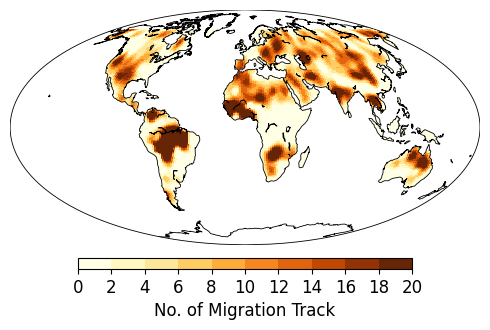

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from mpl_toolkits.basemap import Basemap
from scipy.interpolate import griddata

import geopandas as gpd
from shapely.geometry import Point
from shapely.prepared import prep

# Input and output files
file_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step_4_Event_Calculation\Event_Observ\Track_Count_Grid_5.0_2000-2020.xlsx"
land_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Data\natural_earth_vector\110m_physical\ne_110m_land.shp"

out_png = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\2000-2020_with_Track_Counts_ROBIN.png"
out_pdf = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\2000-2020_with_Track_Counts_ROBIN.pdf"
out_svg = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\2000-2020_with_Track_Counts_ROBIN.svg"

# Read event data
df = pd.read_excel(file_path)

lon = df["centroid_x"].to_numpy(dtype=float)
lat = df["centroid_y"].to_numpy(dtype=float)
val = df["track_count"].to_numpy(dtype=float)

# Remove invalid values
ok = np.isfinite(lon) & np.isfinite(lat) & np.isfinite(val)
lon, lat, val = lon[ok], lat[ok], val[ok]

# Create interpolation grid
grid_lon_1d = np.linspace(-180, 180, 240)
grid_lat_1d = np.linspace(-60, 70, 180)
grid_lon, grid_lat = np.meshgrid(grid_lon_1d, grid_lat_1d)

# Interpolate track counts
interp = griddata(
    (lon, lat),
    val,
    (grid_lon, grid_lat),
    method="cubic"
)

interp = np.where(interp < 0, 0, interp)

land = gpd.read_file(land_path).to_crs("EPSG:4326")

land = land[land.geometry.bounds["maxy"] > -60].copy()

# Merge land polygons
try:
    land_union = land.geometry.union_all()
except AttributeError:
    land_union = land.geometry.unary_union

land_union_p = prep(land_union)

# Create land mask
mask_land = np.zeros(grid_lon.shape, dtype=bool)

for i in range(grid_lon.shape[0]):
    for j in range(grid_lon.shape[1]):
        p = Point(grid_lon[i, j], grid_lat[i, j])
        mask_land[i, j] = land_union_p.intersects(p)

# Apply land mask
interp_land = np.where(mask_land, interp, np.nan)
interp_land = np.ma.masked_invalid(interp_land)

# Set color bins
levels = [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
cmap = plt.get_cmap("YlOrBr", len(levels) - 1)
norm = BoundaryNorm(levels, cmap.N, clip=True)

# Create figure
fig, ax = plt.subplots(figsize=(5, 4))

# Create Mollweide projection
m = Basemap(
    projection="moll",
    lon_0=0,
    resolution="c",
    ax=ax
)

# Draw map boundary
m.drawmapboundary(linewidth=0.6)

# Transform grid coordinates
x, y = m(grid_lon, grid_lat)

# Plot interpolated track-count field
mesh = m.pcolormesh(
    x,
    y,
    interp_land,
    cmap=cmap,
    norm=norm,
    shading="auto"
)

# Draw coastlines
m.drawcoastlines(
    linewidth=0.6,
    color="black"
)

# Add horizontal colorbar
cbar = fig.colorbar(
    mesh,
    ax=ax,
    orientation="horizontal",
    pad=0.04,
    fraction=0.035,
    aspect=30
)

# Format colorbar
cbar.set_label("No. of Migration Track", fontsize=12)
cbar.set_ticks(levels)
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_xticklabels([f"{int(t)}" for t in levels])

# Remove axes
ax.set_axis_off()

# Adjust layout
plt.tight_layout()

# Save PNG
fig.savefig(
    out_png,
    dpi=900,
    bbox_inches="tight",
    transparent=True
)

# Save vector PDF
fig.savefig(
    out_pdf,
    format="pdf",
    bbox_inches="tight",
    transparent=True
)

# Save vector SVG
fig.savefig(
    out_svg,
    format="svg",
    bbox_inches="tight",
    transparent=True
)

# Show figure
plt.show()
plt.close(fig)

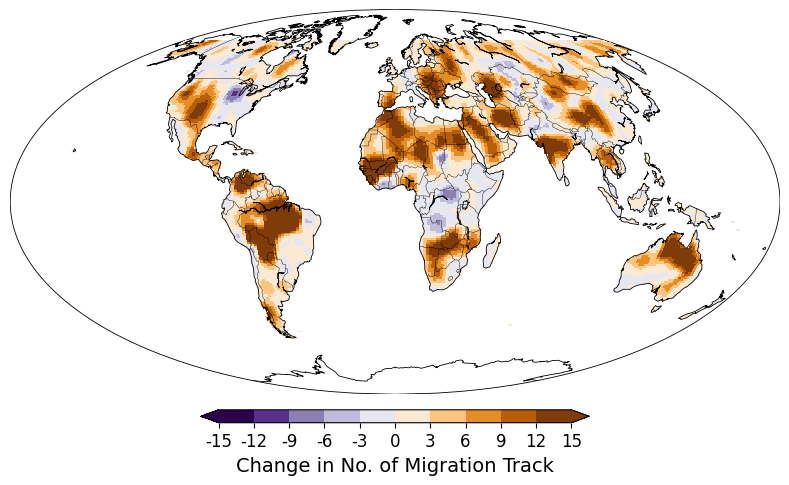

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from mpl_toolkits.basemap import Basemap
from scipy.interpolate import griddata

import geopandas as gpd
from shapely.geometry import Point
from shapely.prepared import prep

# Input and output files
file_path_1980_2000 = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step_4_Event_Calculation\Event_Observ\Track_Count_Grid_5.0_1980-2000.xlsx"
file_path_2000_2020 = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step_4_Event_Calculation\Event_Observ\Track_Count_Grid_5.0_2000-2020.xlsx"
land_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Data\natural_earth_vector\110m_physical\ne_110m_land.shp"

out_png = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\Difference_Asymmetric_PuOr_WholeNumbers_Label16_MOLL.png"
out_pdf = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\Difference_Asymmetric_PuOr_WholeNumbers_Label16_MOLL.pdf"
out_svg = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\Difference_Asymmetric_PuOr_WholeNumbers_Label16_MOLL.svg"

# Read both periods
d1 = pd.read_excel(file_path_1980_2000)
d2 = pd.read_excel(file_path_2000_2020)

lon1 = d1["centroid_x"].to_numpy(dtype=float)
lat1 = d1["centroid_y"].to_numpy(dtype=float)
v1 = d1["track_count"].to_numpy(dtype=float)

lon2 = d2["centroid_x"].to_numpy(dtype=float)
lat2 = d2["centroid_y"].to_numpy(dtype=float)
v2 = d2["track_count"].to_numpy(dtype=float)

# Remove invalid values
ok1 = np.isfinite(lon1) & np.isfinite(lat1) & np.isfinite(v1)
ok2 = np.isfinite(lon2) & np.isfinite(lat2) & np.isfinite(v2)

lon1, lat1, v1 = lon1[ok1], lat1[ok1], v1[ok1]
lon2, lat2, v2 = lon2[ok2], lat2[ok2], v2[ok2]

# Create interpolation grid
grid_lon_1d = np.linspace(-180, 180, 240)
grid_lat_1d = np.linspace(-60, 70, 180)
grid_lon, grid_lat = np.meshgrid(grid_lon_1d, grid_lat_1d)

# Interpolate both periods
interp1 = griddata(
    (lon1, lat1),
    v1,
    (grid_lon, grid_lat),
    method="cubic"
)

interp2 = griddata(
    (lon2, lat2),
    v2,
    (grid_lon, grid_lat),
    method="cubic"
)

# Calculate change between periods
difference = interp2 - interp1

# Read Natural Earth land polygons
land = gpd.read_file(land_path).to_crs("EPSG:4326")

# Remove Antarctica
land = land[land.geometry.bounds["maxy"] > -60].copy()

# Merge land polygons
try:
    land_union = land.geometry.union_all()
except AttributeError:
    land_union = land.geometry.unary_union

land_union_p = prep(land_union)

# Create land mask
land_mask = np.zeros(grid_lon.shape, dtype=bool)

for i in range(grid_lon.shape[0]):
    for j in range(grid_lon.shape[1]):
        p = Point(grid_lon[i, j], grid_lat[i, j])
        land_mask[i, j] = land_union_p.intersects(p)

# Apply land mask
difference_masked = np.where(land_mask, difference, np.nan)
difference_masked = np.ma.masked_invalid(difference_masked)

# Set asymmetric whole-number levels
neg = np.array([-15, -12, -9, -6, -3, 0])
pos = np.array([3, 6, 9, 12, 15])
levels = np.concatenate([neg, pos])

# Create discrete diverging colormap
cmap = plt.get_cmap("PuOr_r", len(levels) - 1)
norm = BoundaryNorm(levels, cmap.N, clip=True)

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Create Mollweide projection
m = Basemap(
    projection="moll",
    lon_0=0,
    resolution="c",
    ax=ax
)

# Draw map boundary
m.drawmapboundary(linewidth=0.6)

# Transform grid coordinates
x, y = m(grid_lon, grid_lat)

# Plot difference field without contourpy
mesh = m.pcolormesh(
    x,
    y,
    difference_masked,
    cmap=cmap,
    norm=norm,
    shading="auto"
)

# Draw coastlines and countries
m.drawcoastlines(linewidth=0.6, color="black")
m.drawcountries(linewidth=0.3, color="black")

# Add horizontal colorbar
cbar = fig.colorbar(
    mesh,
    ax=ax,
    orientation="horizontal",
    pad=0.03,
    fraction=0.025,
    aspect=30,
    extend="both"
)

# Format colorbar
cbar.set_label("Change in No. of Migration Track", fontsize=14)
cbar.set_ticks(levels)
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_xticklabels([f"{int(t)}" for t in levels])

# Remove axes
ax.set_axis_off()

# Adjust layout
plt.tight_layout()

# Save PNG
fig.savefig(
    out_png,
    dpi=900,
    bbox_inches="tight",
    transparent=True
)

# Save vector PDF
fig.savefig(
    out_pdf,
    format="pdf",
    bbox_inches="tight",
    transparent=True
)

# Save vector SVG
fig.savefig(
    out_svg,
    format="svg",
    bbox_inches="tight",
    transparent=True
)

# Show figure
plt.show()
plt.close(fig)

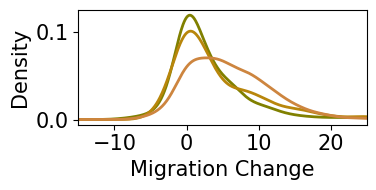

Saved PNG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\KDE_Migration_Change_Aridity.png
Saved PDF: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\KDE_Migration_Change_Aridity.pdf
Saved SVG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\KDE_Migration_Change_Aridity.svg


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Input and output files
migration_file = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step_4_Event_Calculation\Event_Observ\Migration_Change_LandOnly.xlsx"

out_png = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\KDE_Migration_Change_Aridity.png"
out_pdf = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\KDE_Migration_Change_Aridity.pdf"
out_svg = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\KDE_Migration_Change_Aridity.svg"

# Read data
df = pd.read_excel(migration_file)

# Define category colors
colors = {
    "Humid": "olive",
    "Semi-Arid": "darkgoldenrod",
    "Arid": "peru"
}

# Create figure with transparent background
fig, ax = plt.subplots(
    figsize=(4, 2),
    facecolor="none"
)

fig.patch.set_alpha(0)
ax.patch.set_alpha(0)
ax.set_facecolor("none")

# Define common x-axis for KDE curves
x_grid = np.linspace(-15, 25, 500)

# Plot KDE for each aridity class
for category in ["Humid", "Semi-Arid", "Arid"]:

    subset = df.loc[
        df["Aridity Class"] == category,
        "Migration_Change"
    ].dropna().to_numpy(dtype=float)

    if len(subset) > 1:

        kde = gaussian_kde(
            subset,
            bw_method="silverman"
        )

        density = kde(x_grid)

        ax.plot(
            x_grid,
            density,
            color=colors[category],
            linewidth=2,
            label=category
        )

# Set axis range
ax.set_xlim(-15, 25)

# Set axis labels
ax.set_xlabel(
    "Migration Change",
    fontsize=15
)

ax.set_ylabel(
    "Density",
    fontsize=15
)

# Set tick font size
ax.tick_params(
    axis="both",
    which="major",
    labelsize=15
)

# Keep axis background transparent
ax.set_facecolor("none")

# Adjust layout
plt.tight_layout()

# Save high-resolution transparent PNG
fig.savefig(
    out_png,
    dpi=900,
    bbox_inches="tight",
    pad_inches=0.01,
    transparent=True,
    facecolor="none",
    edgecolor="none"
)

# Save transparent vector PDF
fig.savefig(
    out_pdf,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.01,
    transparent=True,
    facecolor="none",
    edgecolor="none"
)

# Save transparent vector SVG
fig.savefig(
    out_svg,
    format="svg",
    bbox_inches="tight",
    pad_inches=0.01,
    transparent=True,
    facecolor="none",
    edgecolor="none"
)

# Display and close figure
plt.show()
plt.close(fig)

print("Saved PNG:", out_png)
print("Saved PDF:", out_pdf)
print("Saved SVG:", out_svg)

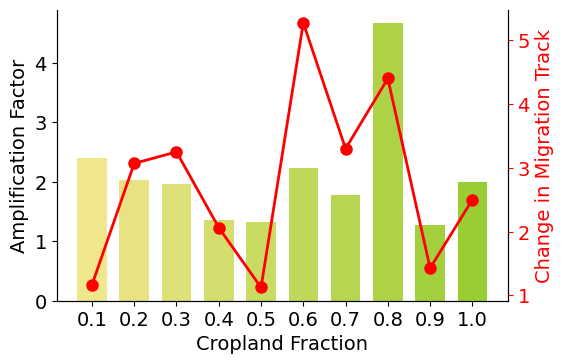

Saved PNG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\combined_plot_adjusted_markers.png
Saved PDF: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\combined_plot_adjusted_markers.pdf
Saved SVG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\combined_plot_adjusted_markers.svg


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# Input files
file_path_previous = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step_4_Event_Calculation\Event_Observ\Track_Count_Grid_5.0_1980-2000_with_cropland_pasture.xlsx"

file_path_recent = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step_4_Event_Calculation\Event_Observ\Track_Count_Grid_5.0_2000-2020_with_cropland_pasture.xlsx"

# Output files
out_png = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\combined_plot_adjusted_markers.png"
out_pdf = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\combined_plot_adjusted_markers.pdf"
out_svg = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\combined_plot_adjusted_markers.svg"

# Read data
df_previous = pd.read_excel(file_path_previous)
df_recent = pd.read_excel(file_path_recent)

# Define cropland-fraction bins
bins = np.arange(0, 1.1, 0.1)
labels = np.round(bins[1:], 1)

# Bin cropland fraction
df_previous["cropland_bin"] = pd.cut(
    df_previous["cropland"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df_recent["cropland_bin"] = pd.cut(
    df_recent["cropland"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Calculate mean track counts
mean_track_count_previous = (
    df_previous.groupby(
        "cropland_bin",
        observed=False
    )["track_count"].mean()
)

mean_track_count_recent = (
    df_recent.groupby(
        "cropland_bin",
        observed=False
    )["track_count"].mean()
)

# Calculate amplification factor and absolute change
amplification_factor = (
    mean_track_count_recent /
    mean_track_count_previous
)

difference = (
    mean_track_count_recent -
    mean_track_count_previous
)

# Align values with all cropland bins
amplification_factor = amplification_factor.reindex(labels).to_numpy(dtype=float)
difference = difference.reindex(labels).to_numpy(dtype=float)

# Create cropland bar colors
cmap = mcolors.LinearSegmentedColormap.from_list(
    "YellowGreen",
    ["khaki", "yellowgreen"]
)

colors = cmap(
    np.linspace(
        0,
        1,
        len(labels)
    )
)

# Create transparent figure
fig, ax1 = plt.subplots(
    figsize=(6, 4),
    facecolor="none"
)

fig.patch.set_alpha(0)
ax1.patch.set_alpha(0)
ax1.set_facecolor("none")

# Define bar positions
bar_positions = np.arange(len(labels))
bar_width = 0.7

# Plot amplification-factor bars
ax1.bar(
    bar_positions,
    amplification_factor,
    color=colors,
    width=bar_width,
    edgecolor="none"
)

# Format primary axis
ax1.set_xlabel(
    "Cropland Fraction",
    fontsize=14
)

ax1.set_ylabel(
    "Amplification Factor",
    fontsize=14
)

ax1.set_xticks(
    bar_positions
)

ax1.set_xticklabels(
    [f"{x:.1f}" for x in labels],
    fontsize=14
)

ax1.tick_params(
    axis="y",
    labelsize=14
)

# Create transparent secondary axis
ax2 = ax1.twinx()
ax2.patch.set_alpha(0)
ax2.set_facecolor("none")

# Plot change in migration tracks
ax2.plot(
    bar_positions,
    difference,
    color="red",
    marker="o",
    markersize=8,
    linestyle="-",
    linewidth=2
)

# Format secondary axis
ax2.set_ylabel(
    "Change in Migration Track",
    fontsize=14,
    color="red"
)

ax2.tick_params(
    axis="y",
    labelsize=14,
    colors="red"
)

# Remove top spines
ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

# Remove grid lines
ax1.grid(False)
ax2.grid(False)

# Adjust layout
plt.tight_layout(pad=2)

# Save transparent high-resolution PNG
fig.savefig(
    out_png,
    dpi=900,
    transparent=True,
    facecolor="none",
    edgecolor="none",
    bbox_inches="tight",
    pad_inches=0.01
)

# Save transparent vector PDF
fig.savefig(
    out_pdf,
    format="pdf",
    transparent=True,
    facecolor="none",
    edgecolor="none",
    bbox_inches="tight",
    pad_inches=0.01
)

# Save transparent vector SVG
fig.savefig(
    out_svg,
    format="svg",
    transparent=True,
    facecolor="none",
    edgecolor="none",
    bbox_inches="tight",
    pad_inches=0.01
)

# Display and close figure
plt.show()
plt.close(fig)

print("Saved PNG:", out_png)
print("Saved PDF:", out_pdf)
print("Saved SVG:", out_svg)

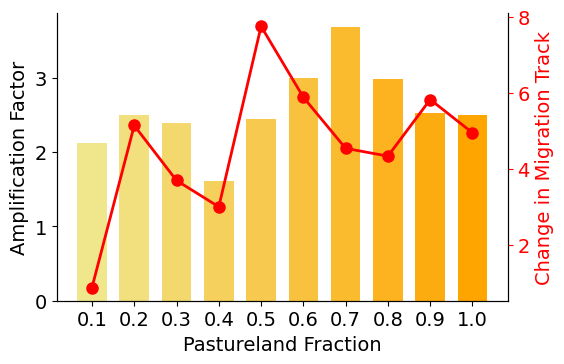

Saved PNG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\combined_pastureland_plot.png
Saved PDF: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\combined_pastureland_plot.pdf
Saved SVG: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\combined_pastureland_plot.svg


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# Input files
file_path_previous = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step_4_Event_Calculation\Event_Observ\Track_Count_Grid_5.0_1980-2000_with_cropland_pasture.xlsx"

file_path_recent = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step_4_Event_Calculation\Event_Observ\Track_Count_Grid_5.0_2000-2020_with_cropland_pasture.xlsx"

# Output files
out_png = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\combined_pastureland_plot.png"
out_pdf = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\combined_pastureland_plot.pdf"
out_svg = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Plots\combined_pastureland_plot.svg"

# Read data
df_previous = pd.read_excel(file_path_previous)
df_recent = pd.read_excel(file_path_recent)

# Define pasture-fraction bins
bins = np.arange(0, 1.1, 0.1)
labels = np.round(bins[1:], 1)

# Bin pasture fraction
df_previous["pasture_bin"] = pd.cut(
    df_previous["pasture"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df_recent["pasture_bin"] = pd.cut(
    df_recent["pasture"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Calculate mean track counts
mean_track_count_previous = (
    df_previous.groupby(
        "pasture_bin",
        observed=False
    )["track_count"].mean()
)

mean_track_count_recent = (
    df_recent.groupby(
        "pasture_bin",
        observed=False
    )["track_count"].mean()
)

# Calculate amplification factor and absolute change
amplification_factor = (
    mean_track_count_recent /
    mean_track_count_previous
)

difference = (
    mean_track_count_recent -
    mean_track_count_previous
)

# Convert results to arrays
amplification_factor = amplification_factor.reindex(labels).to_numpy(dtype=float)
difference = difference.reindex(labels).to_numpy(dtype=float)

# Create bar colors
cmap = mcolors.LinearSegmentedColormap.from_list(
    "YellowOrange",
    ["khaki", "orange"]
)

colors = cmap(
    np.linspace(
        0,
        1,
        len(labels)
    )
)

# Create transparent figure
fig, ax1 = plt.subplots(
    figsize=(6, 4),
    facecolor="none"
)

fig.patch.set_alpha(0)
ax1.patch.set_alpha(0)
ax1.set_facecolor("none")

# Define bar positions
bar_positions = np.arange(len(labels))
bar_width = 0.7

# Plot amplification-factor bars
ax1.bar(
    bar_positions,
    amplification_factor,
    color=colors,
    width=bar_width,
    edgecolor="none"
)

# Format primary axis
ax1.set_xlabel(
    "Pastureland Fraction",
    fontsize=14
)

ax1.set_ylabel(
    "Amplification Factor",
    fontsize=14
)

ax1.set_xticks(
    bar_positions
)

ax1.set_xticklabels(
    [f"{x:.1f}" for x in labels],
    fontsize=14
)

ax1.tick_params(
    axis="y",
    labelsize=14
)

# Create transparent secondary axis
ax2 = ax1.twinx()
ax2.patch.set_alpha(0)
ax2.set_facecolor("none")

# Plot change in migration tracks
ax2.plot(
    bar_positions,
    difference,
    color="red",
    marker="o",
    markersize=8,
    linestyle="-",
    linewidth=2
)

# Format secondary axis
ax2.set_ylabel(
    "Change in Migration Track",
    fontsize=14,
    color="red"
)

ax2.tick_params(
    axis="y",
    labelsize=14,
    colors="red"
)

# Remove top spines
ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

# Remove grid lines
ax1.grid(False)
ax2.grid(False)

# Adjust layout
plt.tight_layout(pad=2)

# Save transparent high-resolution PNG
fig.savefig(
    out_png,
    dpi=900,
    transparent=True,
    facecolor="none",
    edgecolor="none",
    bbox_inches="tight",
    pad_inches=0.01
)

# Save transparent vector PDF
fig.savefig(
    out_pdf,
    format="pdf",
    transparent=True,
    facecolor="none",
    edgecolor="none",
    bbox_inches="tight",
    pad_inches=0.01
)

# Save transparent vector SVG
fig.savefig(
    out_svg,
    format="svg",
    transparent=True,
    facecolor="none",
    edgecolor="none",
    bbox_inches="tight",
    pad_inches=0.01
)

# Display and close figure
plt.show()
plt.close(fig)

print("Saved PNG:", out_png)
print("Saved PDF:", out_pdf)
print("Saved SVG:", out_svg)

Matched grids:
Cropland grids: 32 | found in TrackCount: 32
Pasture grids: 89 | found in TrackCount: 89
Saved Excel: D:\PhD_Research\Paper-3_CHDW_Migration\Data\Cropland_Pasture_Area_Geotiff\CroplandPastureArea2000_Geotiff\TotalTrackCount_TimeSeries_Cropland_vs_Pasture.xlsx


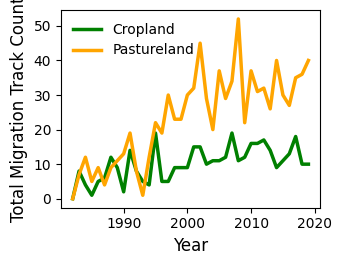

Saved PNG: D:\PhD_Research\Paper-3_CHDW_Migration\Data\Cropland_Pasture_Area_Geotiff\CroplandPastureArea2000_Geotiff\TotalTrackCount_TimeSeries_Cropland_vs_Pasture.png
Saved PDF: D:\PhD_Research\Paper-3_CHDW_Migration\Data\Cropland_Pasture_Area_Geotiff\CroplandPastureArea2000_Geotiff\TotalTrackCount_TimeSeries_Cropland_vs_Pasture.pdf
Saved SVG: D:\PhD_Research\Paper-3_CHDW_Migration\Data\Cropland_Pasture_Area_Geotiff\CroplandPastureArea2000_Geotiff\TotalTrackCount_TimeSeries_Cropland_vs_Pasture.svg


In [26]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Input and output paths
BASE = r"D:\PhD_Research\Paper-3_CHDW_Migration\Data\Cropland_Pasture_Area_Geotiff\CroplandPastureArea2000_Geotiff"

crop_grids_xlsx = os.path.join(
    BASE,
    "Cropland2000_5deg_cells_ge_0p5.xlsx"
)

pasture_grids_xlsx = os.path.join(
    BASE,
    "Pasture2000_5deg_cells_ge_0p5.xlsx"
)

track_xlsx = os.path.join(
    BASE,
    "TrackCount.xlsx"
)

out_xlsx = os.path.join(
    BASE,
    "TotalTrackCount_TimeSeries_Cropland_vs_Pasture.xlsx"
)

out_png = os.path.join(
    BASE,
    "TotalTrackCount_TimeSeries_Cropland_vs_Pasture.png"
)

out_pdf = os.path.join(
    BASE,
    "TotalTrackCount_TimeSeries_Cropland_vs_Pasture.pdf"
)

out_svg = os.path.join(
    BASE,
    "TotalTrackCount_TimeSeries_Cropland_vs_Pasture.svg"
)

START_YEAR = 1982
END_YEAR = 2019

# Read and clean grid-cell list
def clean_grid_list(path):
    g = pd.read_excel(path)
    g.columns = [str(c).strip() for c in g.columns]

    if "Longitude" not in g.columns or "Latitude" not in g.columns:
        g = g.rename(
            columns={
                g.columns[0]: "Longitude",
                g.columns[1]: "Latitude"
            }
        )

    g["Longitude"] = pd.to_numeric(
        g["Longitude"],
        errors="coerce"
    )

    g["Latitude"] = pd.to_numeric(
        g["Latitude"],
        errors="coerce"
    )

    g = g.dropna(
        subset=["Longitude", "Latitude"]
    ).copy()

    g["Longitude"] = g["Longitude"].round(4)
    g["Latitude"] = g["Latitude"].round(4)

    return g.drop_duplicates(
        subset=["Longitude", "Latitude"]
    ).reset_index(drop=True)

# Identify year columns
def get_year_cols(df, start_year, end_year):
    cols = [
        str(y)
        for y in range(start_year, end_year + 1)
        if str(y) in df.columns
    ]

    if not cols:
        raise ValueError(
            "No year columns found in TrackCount file."
        )

    return cols

# Match track-count cells to selected land-use grids
def subset_tracks_by_grids(track_df, grids_df):
    t = track_df.copy()

    t["Longitude"] = pd.to_numeric(
        t["Longitude"],
        errors="coerce"
    ).round(4)

    t["Latitude"] = pd.to_numeric(
        t["Latitude"],
        errors="coerce"
    ).round(4)

    t = t.dropna(
        subset=["Longitude", "Latitude"]
    ).copy()

    t["key"] = list(
        zip(
            t["Longitude"],
            t["Latitude"]
        )
    )

    gkey = set(
        zip(
            grids_df["Longitude"],
            grids_df["Latitude"]
        )
    )

    return t[
        t["key"].isin(gkey)
    ].copy()

# Read cropland and pasture grid lists
crop_grids = clean_grid_list(
    crop_grids_xlsx
)

pasture_grids = clean_grid_list(
    pasture_grids_xlsx
)

# Read migration track-count file
df_track = pd.read_excel(
    track_xlsx
)

df_track.columns = [
    str(c).strip()
    for c in df_track.columns
]

# Standardize longitude and latitude column names
if "Longitude" not in df_track.columns or "Latitude" not in df_track.columns:
    df_track = df_track.rename(
        columns={
            df_track.columns[0]: "Longitude",
            df_track.columns[1]: "Latitude"
        }
    )

# Identify requested year columns
year_cols = get_year_cols(
    df_track,
    START_YEAR,
    END_YEAR
)

# Convert yearly values to numeric
for c in year_cols:
    df_track[c] = pd.to_numeric(
        df_track[c],
        errors="coerce"
    )

# Match cropland and pasture grids
crop_tracks = subset_tracks_by_grids(
    df_track,
    crop_grids
)

pasture_tracks = subset_tracks_by_grids(
    df_track,
    pasture_grids
)

print("Matched grids:")
print(
    "Cropland grids:",
    len(crop_grids),
    "| found in TrackCount:",
    len(crop_tracks)
)

print(
    "Pasture grids:",
    len(pasture_grids),
    "| found in TrackCount:",
    len(pasture_tracks)
)

# Calculate yearly total migration track counts
crop_total = crop_tracks[
    year_cols
].sum(
    axis=0,
    skipna=True
)

past_total = pasture_tracks[
    year_cols
].sum(
    axis=0,
    skipna=True
)

# Create yearly output table
out = pd.DataFrame({
    "year": [
        int(y)
        for y in crop_total.index
    ],
    "total_trackcount_cropland": crop_total.values,
    "total_trackcount_pasture": past_total.reindex(
        crop_total.index
    ).values,
    "n_grids_cropland": len(crop_tracks),
    "n_grids_pasture": len(pasture_tracks)
})

# Save yearly values to Excel
out.to_excel(
    out_xlsx,
    index=False
)

print("Saved Excel:", out_xlsx)

# Create transparent figure
fig, ax = plt.subplots(
    figsize=(3.52, 2.75),
    facecolor="none"
)

fig.patch.set_alpha(0)
ax.patch.set_alpha(0)
ax.set_facecolor("none")

# Plot cropland time series
ax.plot(
    out["year"],
    out["total_trackcount_cropland"],
    linewidth=2.5,
    color="green",
    label="Cropland"
)

# Plot pastureland time series
ax.plot(
    out["year"],
    out["total_trackcount_pasture"],
    linewidth=2.5,
    color="orange",
    label="Pastureland"
)

# Set axis labels
ax.set_xlabel(
    "Year",
    fontsize=12
)

ax.set_ylabel(
    "Total Migration Track Count",
    fontsize=12
)

# Set tick font size
ax.tick_params(
    axis="both",
    labelsize=10
)

# Hide grid lines
ax.grid(
    False
)

# Add legend
ax.legend(
    frameon=False,
    fontsize=10
)

# Adjust layout
plt.tight_layout()

# Save transparent high-resolution PNG
fig.savefig(
    out_png,
    dpi=900,
    transparent=True,
    facecolor="none",
    edgecolor="none",
    bbox_inches="tight",
    pad_inches=0.01
)

# Save transparent vector PDF
fig.savefig(
    out_pdf,
    format="pdf",
    transparent=True,
    facecolor="none",
    edgecolor="none",
    bbox_inches="tight",
    pad_inches=0.01
)

# Save transparent vector SVG
fig.savefig(
    out_svg,
    format="svg",
    transparent=True,
    facecolor="none",
    edgecolor="none",
    bbox_inches="tight",
    pad_inches=0.01
)

# Display and close figure
plt.show()
plt.close(fig)

print("Saved PNG:", out_png)
print("Saved PDF:", out_pdf)
print("Saved SVG:", out_svg)

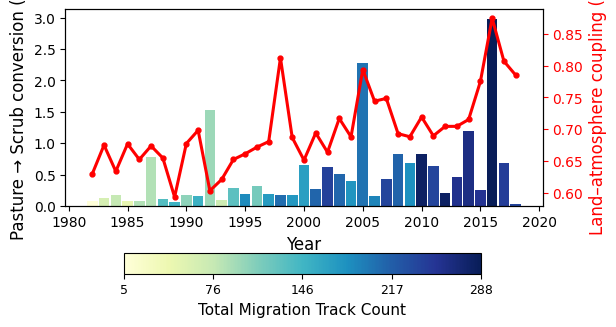

Saved PNG: D:\PhD_Research\Paper-3_CHDW_Migration\Data\hildap_vGLOB-1.0-f_netcdf\Bars_ConversionPct_ColorBy_MigrationTracks_Line_CouplingP_CLEAN.png
Saved PDF: D:\PhD_Research\Paper-3_CHDW_Migration\Data\hildap_vGLOB-1.0-f_netcdf\Bars_ConversionPct_ColorBy_MigrationTracks_Line_CouplingP_CLEAN.pdf
Saved SVG: D:\PhD_Research\Paper-3_CHDW_Migration\Data\hildap_vGLOB-1.0-f_netcdf\Bars_ConversionPct_ColorBy_MigrationTracks_Line_CouplingP_CLEAN.svg

Used columns:
Conversion file: Mean_Pct_Pasture_to_Scrub
Coupling file: p_seasonal_mean


In [29]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import FormatStrFormatter

# Input and output paths
folder = r"D:\PhD_Research\Paper-3_CHDW_Migration\Data\hildap_vGLOB-1.0-f_netcdf"

xlsx_conv = os.path.join(
    folder,
    "Pct_Pasture_to_Scrub_5deg_cells_1982_2019_WIDE_FILTERED_ge0p5_GLOBAL_MEAN_BY_YEAR.xlsx"
)

xlsx_tracks = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step_4_Event_Calculation\Event_Observ\TrackCountGrid_5deg_1982-2019.xlsx"

xlsx_p = r"D:\PhD_Research\Paper-3_CHDW_Migration\Data\NCEP\Annual_SeasonalMean_p_PastureGrids_1982_2019.xlsx"

out_png = os.path.join(
    folder,
    "Bars_ConversionPct_ColorBy_MigrationTracks_Line_CouplingP_CLEAN.png"
)

out_pdf = os.path.join(
    folder,
    "Bars_ConversionPct_ColorBy_MigrationTracks_Line_CouplingP_CLEAN.pdf"
)

out_svg = os.path.join(
    folder,
    "Bars_ConversionPct_ColorBy_MigrationTracks_Line_CouplingP_CLEAN.svg"
)

START_YEAR = 1982
END_YEAR = 2018

# Read yearly pasture-to-scrub conversion
df_conv = pd.read_excel(xlsx_conv)
df_conv.columns = [str(c).strip() for c in df_conv.columns]

YEARC = next(
    (c for c in df_conv.columns if c.lower() in ["year", "years"]),
    df_conv.columns[0]
)

val_candidates = [
    c for c in df_conv.columns
    if c != YEARC
]

pref = [
    c for c in val_candidates
    if (
        "mean" in c.lower()
        or "pct" in c.lower()
        or "pasture" in c.lower()
    )
]

CONVC = pref[0] if pref else val_candidates[0]

df_conv[YEARC] = pd.to_numeric(
    df_conv[YEARC],
    errors="coerce"
)

df_conv[CONVC] = pd.to_numeric(
    df_conv[CONVC],
    errors="coerce"
)

df_conv = df_conv.dropna(
    subset=[YEARC, CONVC]
).copy()

df_conv = df_conv.rename(
    columns={
        YEARC: "year",
        CONVC: "conv_pct"
    }
)

df_conv["year"] = df_conv["year"].astype(int)

# Read migration tracks and calculate yearly global totals
df_t = pd.read_excel(xlsx_tracks)
df_t.columns = [str(c).strip() for c in df_t.columns]

years_needed = np.arange(
    START_YEAR,
    END_YEAR + 1
).astype(int)

year_cols = [
    str(y)
    for y in years_needed
    if str(y) in df_t.columns
]

if len(year_cols) == 0:
    raise ValueError("No requested year columns found in migration-track file.")

tracks = df_t[year_cols].sum(
    axis=0
)

df_tracks = pd.DataFrame({
    "year": tracks.index.astype(int),
    "track_count": pd.to_numeric(
        tracks.values,
        errors="coerce"
    )
})

# Read yearly land-atmosphere coupling
df_p = pd.read_excel(xlsx_p)
df_p.columns = [str(c).strip() for c in df_p.columns]

PYEAR = next(
    (c for c in df_p.columns if c.lower() in ["year", "years"]),
    df_p.columns[0]
)

p_candidates = [
    c for c in df_p.columns
    if c != PYEAR
]

p_pref = [
    c for c in p_candidates
    if (
        c.lower() == "p"
        or c.lower().startswith("p_")
        or "coupling" in c.lower()
    )
]

PCOL = p_pref[0] if p_pref else p_candidates[0]

df_p[PYEAR] = pd.to_numeric(
    df_p[PYEAR],
    errors="coerce"
)

df_p[PCOL] = pd.to_numeric(
    df_p[PCOL],
    errors="coerce"
)

df_p = df_p.dropna(
    subset=[PYEAR, PCOL]
).copy()

df_p = df_p.rename(
    columns={
        PYEAR: "year",
        PCOL: "p"
    }
)

df_p["year"] = df_p["year"].astype(int)

# Merge the three annual datasets
df = (
    df_conv
    .merge(df_tracks, on="year", how="inner")
    .merge(df_p, on="year", how="inner")
)

df = df[
    (df["year"] >= START_YEAR)
    & (df["year"] <= END_YEAR)
].sort_values(
    "year"
).reset_index(
    drop=True
)

if df.empty:
    raise ValueError(
        "No overlapping years found among the three files."
    )

# Normalize migration-track counts for bar colors
norm = mpl.colors.Normalize(
    vmin=df["track_count"].min(),
    vmax=df["track_count"].max()
)

cmap = plt.cm.YlGnBu

bar_colors = cmap(
    norm(df["track_count"].values)
)

# Create figure
fig, ax1 = plt.subplots(
    figsize=(6.16, 3.39)
)

# Plot conversion bars
ax1.bar(
    df["year"],
    df["conv_pct"],
    color=bar_colors,
    width=0.9,
    edgecolor="none"
)

ax1.set_xlabel(
    "Year",
    fontsize=12
)

ax1.set_ylabel(
    "Pasture → Scrub conversion (%)",
    fontsize=12
)

ax1.tick_params(
    axis="both",
    labelsize=10
)

# Plot coupling line on right axis
ax2 = ax1.twinx()

ax2.plot(
    df["year"],
    df["p"],
    color="red",
    linewidth=2.2,
    marker="o",
    markersize=3.5
)

ax2.set_ylabel(
    "Land–atmosphere coupling (p)",
    fontsize=12,
    color="red"
)

ax2.tick_params(
    axis="y",
    colors="red",
    labelsize=10
)

# Make space for horizontal colorbar
fig.subplots_adjust(
    bottom=0.30
)

# Add dedicated colorbar axis
cax = fig.add_axes([
    0.22,
    0.10,
    0.58,
    0.06
])

sm = mpl.cm.ScalarMappable(
    norm=norm,
    cmap=cmap
)

sm.set_array([])

# Add migration-track colorbar
cbar = fig.colorbar(
    sm,
    cax=cax,
    orientation="horizontal"
)

cbar.set_label(
    "Total Migration Track Count",
    fontsize=11
)

# Set five whole-number colorbar ticks
ticks = np.linspace(
    df["track_count"].min(),
    df["track_count"].max(),
    5
)

cbar.set_ticks(
    ticks
)

cbar.ax.tick_params(
    labelsize=9
)

cbar.ax.xaxis.set_major_formatter(
    FormatStrFormatter("%.0f")
)

# Save high-resolution PNG
fig.savefig(
    out_png,
    dpi=900,
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.01
)

# Save vector PDF
fig.savefig(
    out_pdf,
    format="pdf",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.01
)

# Save vector SVG
fig.savefig(
    out_svg,
    format="svg",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.01
)

# Display and close figure
plt.show()
plt.close(fig)

print("Saved PNG:", out_png)
print("Saved PDF:", out_pdf)
print("Saved SVG:", out_svg)

print("\nUsed columns:")
print("Conversion file:", CONVC)
print("Coupling file:", PCOL)

Both-positive grid cells: 175


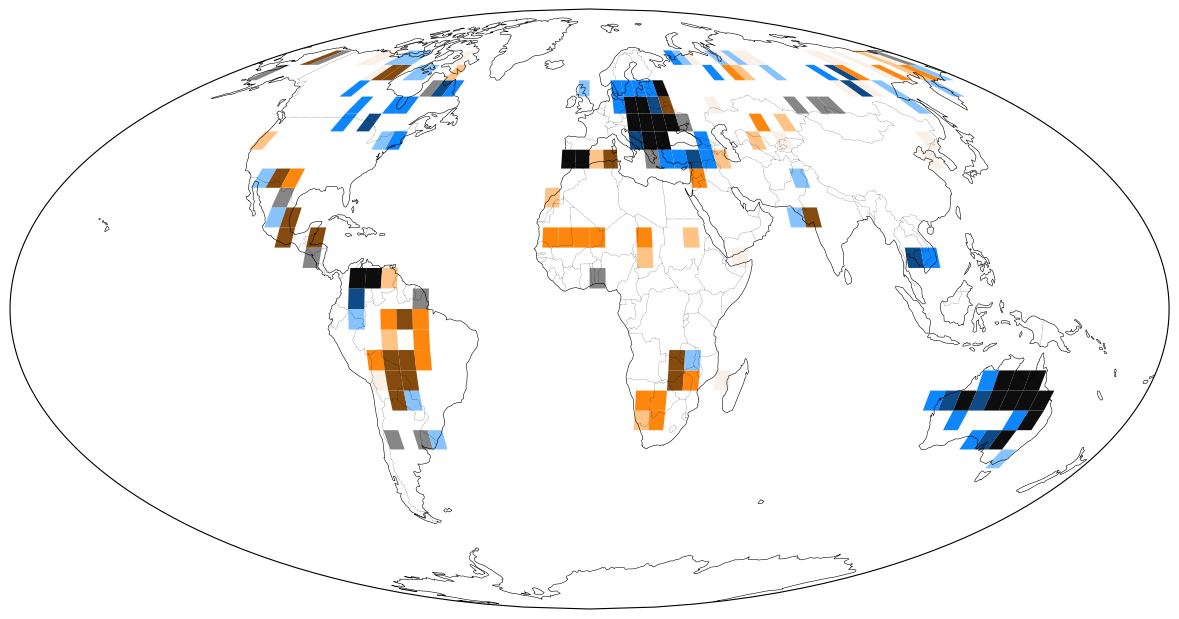

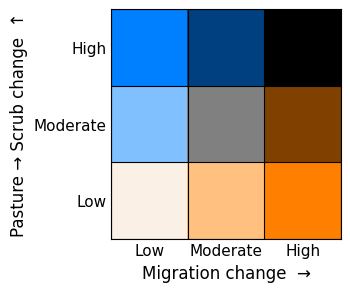

Saved map: D:\PhD_Research\Paper-3_CHDW_Migration\Data\hildap_vGLOB-1.0-f_netcdf\BIVARIATE_BOTH_POSITIVE_Map.png
Saved PDF: D:\PhD_Research\Paper-3_CHDW_Migration\Data\hildap_vGLOB-1.0-f_netcdf\BIVARIATE_BOTH_POSITIVE_Map.pdf
Saved SVG: D:\PhD_Research\Paper-3_CHDW_Migration\Data\hildap_vGLOB-1.0-f_netcdf\BIVARIATE_BOTH_POSITIVE_Map.svg
Saved legend: D:\PhD_Research\Paper-3_CHDW_Migration\Data\hildap_vGLOB-1.0-f_netcdf\BIVARIATE_BOTH_POSITIVE_Legend.png


In [16]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from shapely.geometry import Polygon
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Input and output paths
folder = r"D:\PhD_Research\Paper-3_CHDW_Migration\Data\hildap_vGLOB-1.0-f_netcdf"

in_xlsx = os.path.join(
    folder,
    "BIVARIATE_ALL_GRIDCELLS_Classified.xlsx"
)

land_path = r"D:\PhD_Research\Paper-3_CHDW_Migration\Data\natural_earth_vector\110m_physical\ne_110m_land.shp"

out_map_png = os.path.join(
    folder,
    "BIVARIATE_BOTH_POSITIVE_Map.png"
)

out_map_pdf = os.path.join(
    folder,
    "BIVARIATE_BOTH_POSITIVE_Map.pdf"
)

out_map_svg = os.path.join(
    folder,
    "BIVARIATE_BOTH_POSITIVE_Map.svg"
)

out_legend_png = os.path.join(
    folder,
    "BIVARIATE_BOTH_POSITIVE_Legend.png"
)

GRID_SIZE = 5.0

# Read already-classified Excel
df = pd.read_excel(in_xlsx)
df.columns = [str(c).strip() for c in df.columns]

# Convert required columns to numeric
numeric_cols = [
    "Longitude",
    "Latitude",
    "Migration_difference",
    "LandConversion_difference",
    "mig_bin",
    "lc_bin",
    "bivar"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove invalid rows
df = df.dropna(
    subset=[
        "Longitude",
        "Latitude",
        "Migration_difference",
        "LandConversion_difference",
        "mig_bin",
        "lc_bin",
        "bivar"
    ]
).copy()

# Keep ONLY cells where both variables increased
df = df[
    (df["Migration_difference"] > 0) &
    (df["LandConversion_difference"] > 0)
].copy()

print("Both-positive grid cells:", len(df))

# Convert classes to integers
df["mig_bin"] = df["mig_bin"].astype(int)
df["lc_bin"] = df["lc_bin"].astype(int)
df["bivar"] = df["bivar"].astype(int)

# Build 5° × 5° square polygons
half = GRID_SIZE / 2.0
polys = []

for lon, lat in zip(df["Longitude"], df["Latitude"]):
    polys.append(
        Polygon([
            (lon - half, lat - half),
            (lon + half, lat - half),
            (lon + half, lat + half),
            (lon - half, lat + half)
        ])
    )

gdf = gpd.GeoDataFrame(
    df.copy(),
    geometry=polys,
    crs="EPSG:4326"
)

# Read Natural Earth land
land = gpd.read_file(land_path)

if land.crs is None:
    land = land.set_crs("EPSG:4326")
else:
    land = land.to_crs("EPSG:4326")

# Merge land polygons
try:
    land_union = land.geometry.union_all()
except AttributeError:
    land_union = land.geometry.unary_union

# Keep only cells intersecting land
gdf = gdf[
    gdf.geometry.intersects(land_union)
].copy()

# Define exact 9 bivariate colors
bivar_colors = [
    "#FAF0E6",
    "#FFC080",
    "#FF8000",
    "#80C0FF",
    "#808080",
    "#7F4000",
    "#0080FF",
    "#004080",
    "#000000"
]

bivar_cmap = ListedColormap(bivar_colors)

# Create Mollweide map
fig = plt.figure(figsize=(12, 6))

ax = plt.axes(
    projection=ccrs.Mollweide(
        central_longitude=0
    )
)

ax.set_global()

# Draw coastlines and country borders
ax.add_feature(
    cfeature.COASTLINE,
    linewidth=0.4
)

ax.add_feature(
    cfeature.BORDERS,
    linewidth=0.3,
    linestyle=":"
)

# Plot ONLY both-positive cells
gdf.plot(
    column="bivar",
    cmap=bivar_cmap,
    vmin=0,
    vmax=8,
    linewidth=0,
    edgecolor="none",
    alpha=0.95,
    ax=ax,
    transform=ccrs.PlateCarree()
)

# Remove extra margins
plt.subplots_adjust(
    left=0,
    right=1,
    bottom=0,
    top=1
)

# Save PNG
fig.savefig(
    out_map_png,
    dpi=900,
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.01
)

# Save vector PDF
fig.savefig(
    out_map_pdf,
    format="pdf",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.01
)

# Save vector SVG
fig.savefig(
    out_map_svg,
    format="svg",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.01
)

plt.show()
plt.close(fig)

# Create 3 × 3 bivariate legend
legend_mat = np.array([
    [6, 7, 8],
    [3, 4, 5],
    [0, 1, 2]
])

figL, axL = plt.subplots(figsize=(3.6, 3.6))

axL.imshow(
    legend_mat,
    cmap=bivar_cmap,
    vmin=0,
    vmax=8,
    interpolation="nearest"
)

# Add legend ticks
axL.set_xticks([0, 1, 2])
axL.set_yticks([0, 1, 2])

axL.set_xticklabels(
    ["Low", "Moderate", "High"],
    fontsize=11
)

axL.set_yticklabels(
    ["High", "Moderate", "Low"],
    fontsize=11
)

# Add legend labels
axL.set_xlabel(
    "Migration change  →",
    fontsize=12
)

axL.set_ylabel(
    "Pasture → Scrub change  ↑",
    fontsize=12
)

# Add grid lines
axL.set_xticks(
    np.arange(-0.5, 3, 1),
    minor=True
)

axL.set_yticks(
    np.arange(-0.5, 3, 1),
    minor=True
)

axL.grid(
    which="minor",
    color="black",
    linewidth=0.8
)

axL.tick_params(
    which="both",
    length=0
)

plt.tight_layout()

# Save legend
figL.savefig(
    out_legend_png,
    dpi=900,
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.01
)

plt.show()
plt.close(figL)

print("Saved map:", out_map_png)
print("Saved PDF:", out_map_pdf)
print("Saved SVG:", out_map_svg)
print("Saved legend:", out_legend_png)